# Heart Disease Prediction
---
## Statement
Heart disease is one of the leading causes of death worldwide. The objective of this project
is to build classification models to predict whether a patient has heart disease (target = 0 or 1).

## Objectives
1. Develop supervised classification models.
2. Compare Logistic Regression, Decision Tree, Random Forest, and Neural Network.
3. Evaluate using Accuracy, Precision, Recall, F1-Score, ROC-AUC.
4. Interpret feature importance.
---

# 1️⃣ Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# 2️⃣ Data Understanding & Cleaning

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [4]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# 3️⃣ Exploratory Data Analysis (EDA)

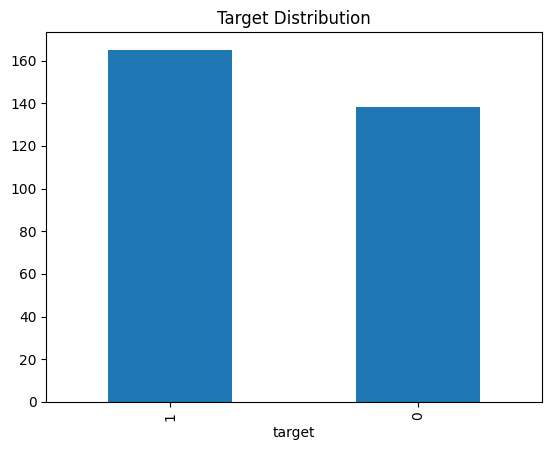

In [5]:
plt.figure()
df['target'].value_counts().plot(kind='bar')
plt.title('Target Distribution')
plt.show()

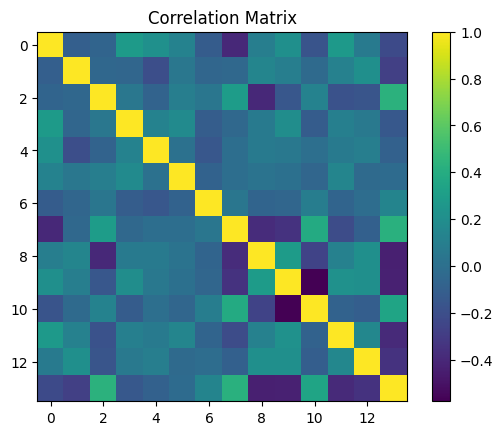

In [6]:
plt.figure()
corr = df.corr()
plt.imshow(corr)
plt.colorbar()
plt.title('Correlation Matrix')
plt.show()

# 4️⃣ Model Building

In [7]:
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 4.1 Logistic Regression

In [8]:
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:,1]

## 4.2 Decision Tree (GridSearchCV)

In [9]:
dt_params = {'max_depth':[3,5,7,None]}
dt_grid = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5)
dt_grid.fit(X_train, y_train)
dt_model = dt_grid.best_estimator_
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:,1]

## 4.3 Random Forest (GridSearchCV)

In [10]:
rf_params = {'n_estimators':[100,200]}
rf_grid = GridSearchCV(RandomForestClassifier(), rf_params, cv=5)
rf_grid.fit(X_train, y_train)
rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:,1]

## 4.4 Feedforward Neural Network

In [11]:
nn_model = MLPClassifier(hidden_layer_sizes=(64,32), max_iter=1000)
nn_model.fit(X_train, y_train)
nn_pred = nn_model.predict(X_test)
nn_prob = nn_model.predict_proba(X_test)[:,1]

# 5️⃣ Model Evaluation


Logistic Regression
Accuracy: 0.8524590163934426
Precision: 0.8709677419354839
Recall: 0.84375
F1-Score: 0.8571428571428571
ROC-AUC: 0.9267241379310345


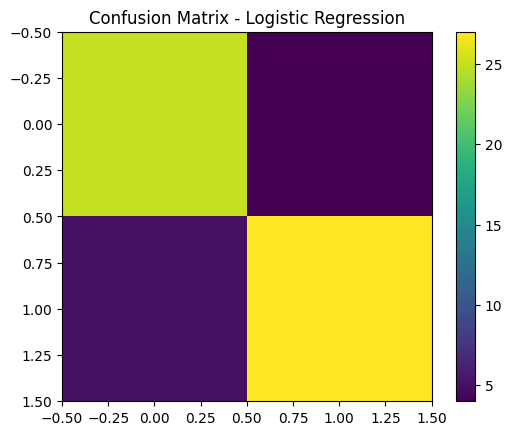


Decision Tree
Accuracy: 0.8360655737704918
Precision: 0.84375
Recall: 0.84375
F1-Score: 0.84375
ROC-AUC: 0.8491379310344828


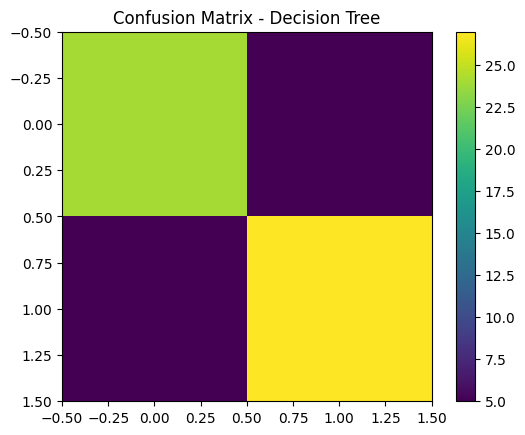


Random Forest
Accuracy: 0.819672131147541
Precision: 0.8387096774193549
Recall: 0.8125
F1-Score: 0.8253968253968254
ROC-AUC: 0.9342672413793104


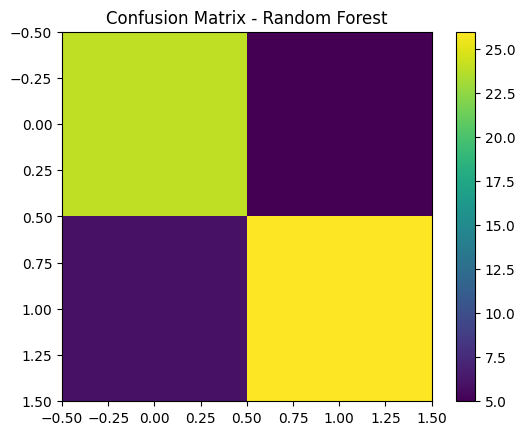


Neural Network
Accuracy: 0.8524590163934426
Precision: 0.896551724137931
Recall: 0.8125
F1-Score: 0.8524590163934426
ROC-AUC: 0.8879310344827587


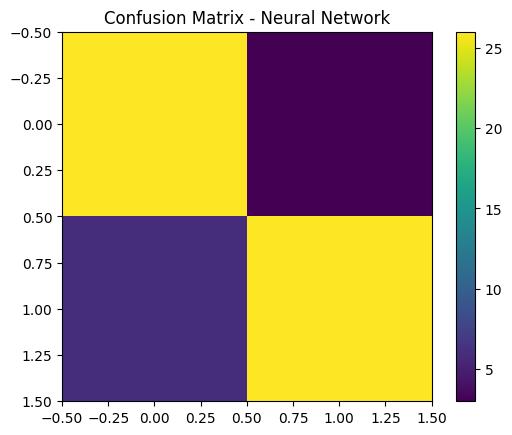

In [12]:
def evaluate_model(y_test, y_pred, y_prob, model_name):
    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-Score:", f1_score(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_prob))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.figure()
    plt.imshow(cm)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.colorbar()
    plt.show()

evaluate_model(y_test, log_pred, log_prob, "Logistic Regression")
evaluate_model(y_test, dt_pred, dt_prob, "Decision Tree")
evaluate_model(y_test, rf_pred, rf_prob, "Random Forest")
evaluate_model(y_test, nn_pred, nn_prob, "Neural Network")

# 6️⃣ Feature Importance Interpretation

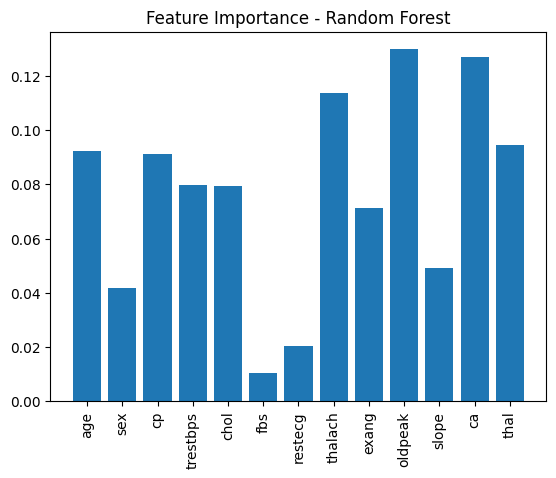

In [13]:
importances = rf_model.feature_importances_
feature_names = df.drop('target', axis=1).columns

plt.figure()
plt.bar(feature_names, importances)
plt.xticks(rotation=90)
plt.title('Feature Importance - Random Forest')
plt.show()